# 🏠 House Price Prediction — End-to-End ML Project
**Goal:** predict a property's sale price (INR lakhs) from its features, using a dataset stored in an Excel file.

**Workflow:** Load Excel → Understand data → Clean → EDA → Feature engineering → Train models → Evaluate & compare → Tune best model → Save & predict.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load the dataset from Excel
The workbook has two sheets: `House_Data` (the data) and `Data_Dictionary` (column descriptions).

In [2]:
xls = pd.ExcelFile('data/house_prices.xlsx')
print('Sheets:', xls.sheet_names)
df = pd.read_excel(xls, sheet_name='House_Data')
pd.read_excel(xls, sheet_name='Data_Dictionary', nrows=13)

Sheets: ['House_Data', 'Data_Dictionary']


,Column,Description,Type
0,House_ID,Unique property identifier,Text
1,Location,Locality / zone of the property,Category (8 zones)
2,Area_sqft,Carpet area in square feet,Number
3,Bedrooms,Number of bedrooms (BHK),Integer
4,Bathrooms,Number of bathrooms,Integer
5,Balconies,Number of balconies,Integer
6,Floor,Floor the flat is on (0 = ground),Integer
7,Total_Floors,Total floors in the building,Integer
8,Age_Years,Age of the property in years,Integer
9,Furnishing,Furnishing status,Unfurnished / Semi-Furnished / Furnished


In [3]:
print(df.shape)
df.head()

(1512, 13)


,House_ID,Location,Area_sqft,Bedrooms,Bathrooms,Balconies,Floor,Total_Floors,Age_Years,Furnishing,Parking_Spaces,Near_Metro,Price_Lakhs
0,H0001,Industrial Area,1467.0,3,3.0,2,3,4,10.0,Furnished,1,No,80.86
1,H0002,Old Town,1579.0,4,3.0,2,3,4,NaN,Unfurnished,0,No,91.01
2,H0003,Outskirts,681.0,2,1.0,3,14,20,3.0,Unfurnished,2,Yes,33.37
3,H0004,Lake View,798.0,2,2.0,1,3,4,4.0,Semi-Furnished,0,No,66.62
4,H0005,City Center,1511.0,3,3.0,2,5,20,6.0,Furnished,0,No,175.64


## 3. Understand the data

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   House_ID        1512 non-null   str    
 1   Location        1512 non-null   str    
 2   Area_sqft       1481 non-null   float64
 3   Bedrooms        1512 non-null   int64  
 4   Bathrooms       1486 non-null   float64
 5   Balconies       1512 non-null   int64  
 6   Floor           1512 non-null   int64  
 7   Total_Floors    1512 non-null   int64  
 8   Age_Years       1472 non-null   float64
 9   Furnishing      1492 non-null   str    
 10  Parking_Spaces  1512 non-null   int64  
 11  Near_Metro      1512 non-null   str    
 12  Price_Lakhs     1512 non-null   float64
dtypes: float64(4), int64(5), str(4)
memory usage: 153.7 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area_sqft,1481.0,1174.861580,348.036431,409.00,937.0000,1143.000,1396.00,2287.0
Bedrooms,1512.0,2.497354,0.987677,1.00,2.0000,2.000,3.00,5.0
Bathrooms,1486.0,2.218708,1.011023,1.00,1.0000,2.000,3.00,5.0
Balconies,1512.0,1.522487,1.111053,0.00,1.0000,2.000,2.00,3.0
Floor,1512.0,5.935185,6.608843,0.00,1.0000,3.000,8.00,30.0
Total_Floors,1512.0,11.886905,9.717371,2.00,4.0000,7.000,20.00,30.0
Age_Years,1472.0,15.211277,9.026560,0.00,7.0000,15.000,23.00,30.0
Parking_Spaces,1512.0,0.939153,0.673013,0.00,0.0000,1.000,1.00,2.0
Price_Lakhs,1512.0,90.823479,60.407041,17.34,57.9775,83.105,111.68,1546.0


In [6]:
print('Missing values:\n', df.isnull().sum()[df.isnull().sum() > 0])
print('\nDuplicate rows:', df.duplicated(subset=df.columns.drop('House_ID')).sum())

Missing values:
 Area_sqft     31
Bathrooms     26
Age_Years     40
Furnishing    20
dtype: int64

Duplicate rows: 12


## 4. Data cleaning
### 4.1 Remove duplicates

In [7]:
df = df.drop_duplicates(subset=df.columns.drop('House_ID')).reset_index(drop=True)
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (1500, 13)


### 4.2 Handle outliers in the target
A few prices are far above everything else. We use the **IQR rule** on price per sqft (fairer than raw price, since big houses are legitimately expensive).

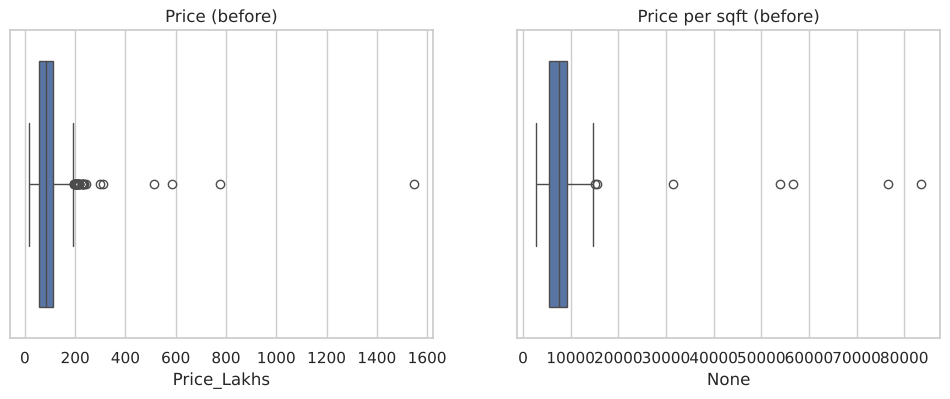

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Price_Lakhs'], ax=ax[0]); ax[0].set_title('Price (before)')
pps = df['Price_Lakhs'] * 1e5 / df['Area_sqft']
sns.boxplot(x=pps, ax=ax[1]); ax[1].set_title('Price per sqft (before)')
plt.show()

In [9]:
df['Price_per_sqft'] = df['Price_Lakhs'] * 1e5 / df['Area_sqft']
q1, q3 = df['Price_per_sqft'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 3 * iqr      # 3*IQR = remove only extreme points
outliers = df['Price_per_sqft'] > upper
print(f'Outliers removed: {outliers.sum()}')
print(df.loc[outliers, ['House_ID','Location','Area_sqft','Price_Lakhs','Price_per_sqft']])
df = df[~outliers].drop(columns='Price_per_sqft').reset_index(drop=True)
print('Shape after outlier removal:', df.shape)

Outliers removed: 5
     House_ID         Location  Area_sqft  Price_Lakhs  Price_per_sqft
607     H0608        Riverside     2021.0      1546.00    76496.783770
805     H0806        Riverside      929.0       775.52    83479.009688
822     H0823        Tech Park      950.0       512.80    53978.947368
862     H0863  Industrial Area      989.0       311.04    31449.949444
1131    H1132     Green Valley     1032.0       584.80    56666.666667
Shape after outlier removal: (1495, 13)


### 4.3 Missing values
We **don't** fill them here — imputation is done inside the ML pipeline (median for numbers, most-frequent for categories) and fitted on training data only. This avoids **data leakage** from the test set.

## 5. Exploratory Data Analysis (EDA)

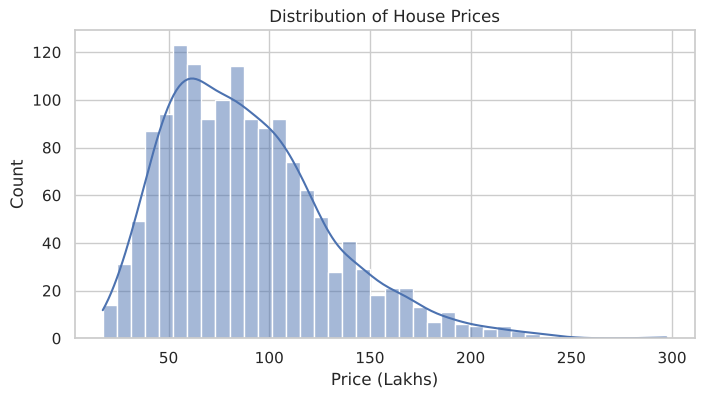

Skewness: 0.91


In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Price_Lakhs'], kde=True, bins=40)
plt.title('Distribution of House Prices'); plt.xlabel('Price (Lakhs)'); plt.show()
print('Skewness:', round(df['Price_Lakhs'].skew(), 2))

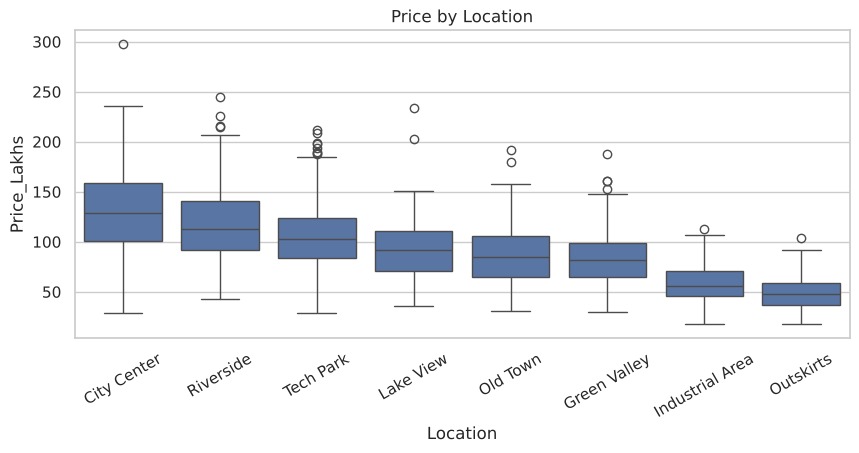

In [11]:
plt.figure(figsize=(10, 4))
order = df.groupby('Location')['Price_Lakhs'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Location', y='Price_Lakhs', order=order)
plt.xticks(rotation=30); plt.title('Price by Location'); plt.show()

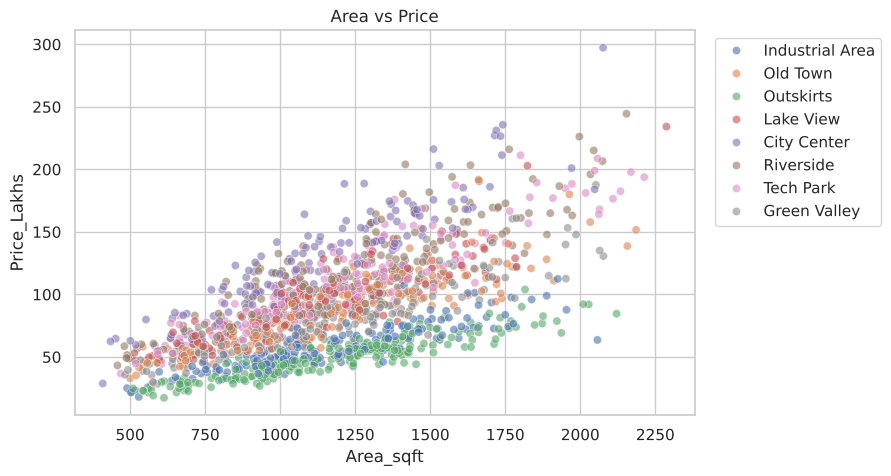

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Area_sqft', y='Price_Lakhs', hue='Location', alpha=0.6)
plt.title('Area vs Price'); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.show()

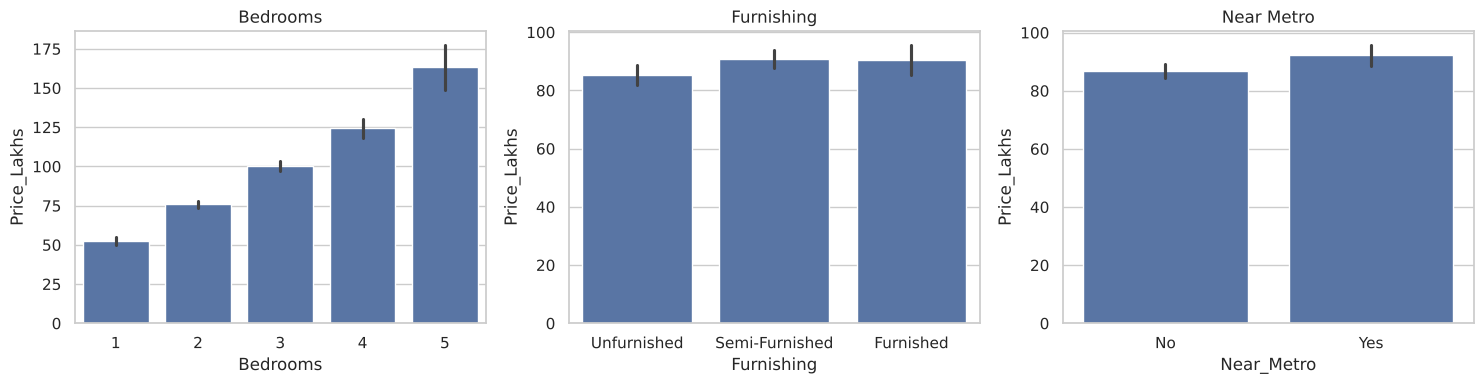

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=df, x='Bedrooms', y='Price_Lakhs', ax=ax[0]); ax[0].set_title('Bedrooms')
sns.barplot(data=df, x='Furnishing', y='Price_Lakhs', ax=ax[1], order=['Unfurnished','Semi-Furnished','Furnished']); ax[1].set_title('Furnishing')
sns.barplot(data=df, x='Near_Metro', y='Price_Lakhs', ax=ax[2]); ax[2].set_title('Near Metro')
plt.tight_layout(); plt.show()

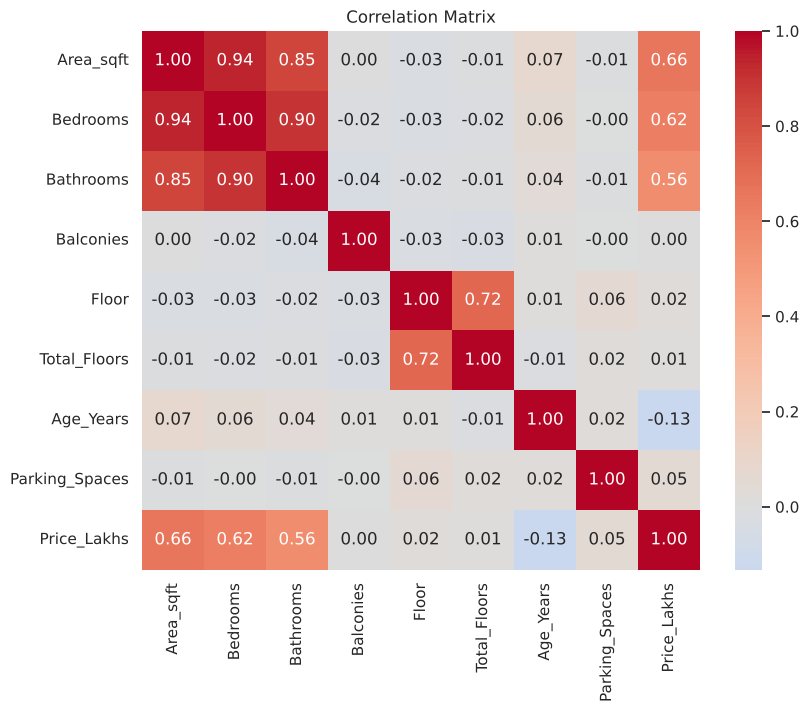

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix'); plt.show()

**Key EDA insights**
- **Area** is the strongest single driver of price.
- **Location** creates large price gaps — central / tech zones cost far more per sqft than the outskirts.
- Furnished homes and homes near a metro station sell at a premium; older homes sell for less.

## 6. Feature engineering

In [15]:
df['Floor_Ratio'] = df['Floor'] / df['Total_Floors']          # relative height in the building
df['Rooms_Total'] = df['Bedrooms'] + df['Bathrooms']
df['Near_Metro'] = df['Near_Metro'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['House_ID', 'Price_Lakhs'])
y = df['Price_Lakhs']

cat_cols = ['Location', 'Furnishing']
num_cols = [c for c in X.columns if c not in cat_cols]
print('Numeric :', num_cols); print('Category:', cat_cols)

Numeric : ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Balconies', 'Floor', 'Total_Floors', 'Age_Years', 'Parking_Spaces', 'Near_Metro', 'Floor_Ratio', 'Rooms_Total']
Category: ['Location', 'Furnishing']


## 7. Train / test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1196, 13) | Test: (299, 13)


## 8. Preprocessing pipeline

In [17]:
preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale',  StandardScaler())]), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
])

## 9. Train & compare models
Each model is evaluated with **5-fold cross-validation** on the training set, then on the held-out test set.

In [18]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

def evaluate(y_true, y_pred):
    return {'MAE':  mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2':   r2_score(y_true, y_pred)}

results, fitted = [], {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2').mean()
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results.append({'Model': name, 'CV_R2': cv_r2, **evaluate(y_test, pipe.predict(X_test))})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).round(3)
results_df

,Model,CV_R2,MAE,RMSE,R2
4,Gradient Boosting,0.905,8.227,12.242,0.916
3,Random Forest,0.892,9.044,13.340,0.901
1,Ridge Regression,0.883,10.649,14.672,0.880
0,Linear Regression,0.883,10.677,14.677,0.880
2,Decision Tree,0.806,12.000,17.013,0.839


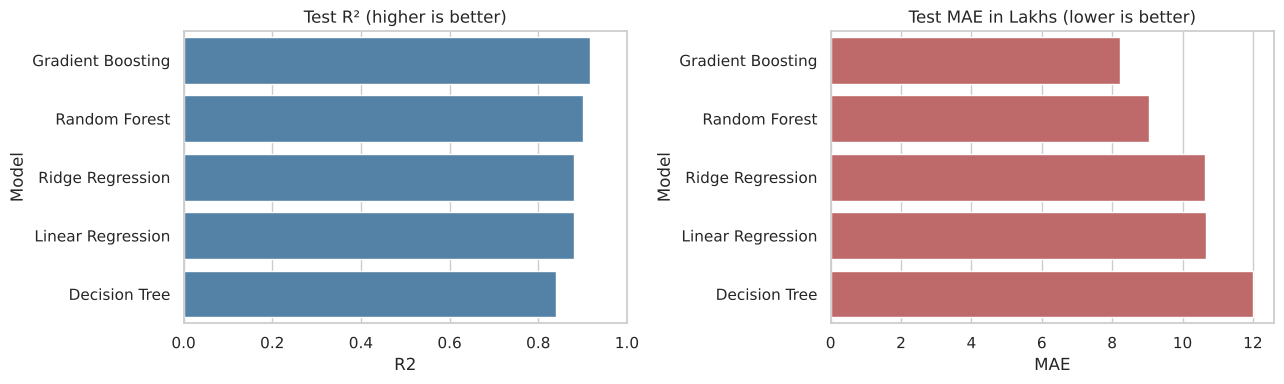

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=results_df, y='Model', x='R2', ax=ax[0], color='steelblue'); ax[0].set_title('Test R² (higher is better)'); ax[0].set_xlim(0, 1)
sns.barplot(data=results_df, y='Model', x='MAE', ax=ax[1], color='indianred'); ax[1].set_title('Test MAE in Lakhs (lower is better)')
plt.tight_layout(); plt.show()

## 10. Hyperparameter tuning (Gradient Boosting)

In [20]:
param_grid = {
    'model__n_estimators': [200, 400],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 4],
}
gb_pipe = Pipeline([('prep', preprocess), ('model', GradientBoostingRegressor(random_state=42))])
grid = GridSearchCV(gb_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print('Best params:', grid.best_params_)
print('Best CV R² :', round(grid.best_score_, 3))
print('Test metrics:', {k: round(v, 3) for k, v in evaluate(y_test, best_model.predict(X_test)).items()})

Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 400}
Best CV R² : 0.91
Test metrics: {'MAE': 8.191, 'RMSE': np.float64(12.106), 'R2': 0.918}


## 11. Evaluate the final model

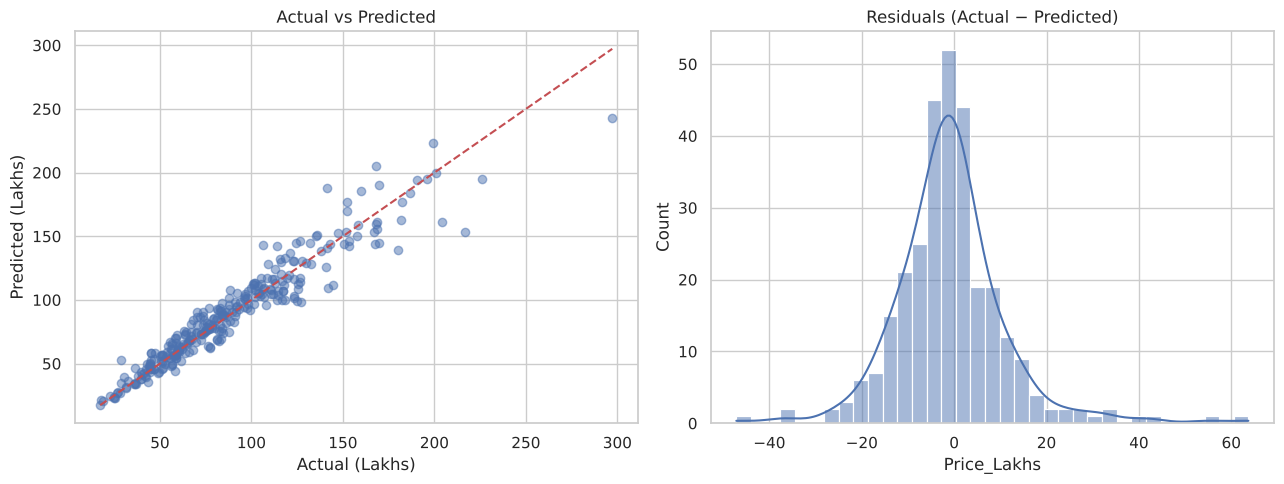

In [21]:
y_pred = best_model.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, y_pred, alpha=0.5)
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, 'r--'); ax[0].set_xlabel('Actual (Lakhs)'); ax[0].set_ylabel('Predicted (Lakhs)')
ax[0].set_title('Actual vs Predicted')
sns.histplot(y_test - y_pred, kde=True, ax=ax[1]); ax[1].set_title('Residuals (Actual − Predicted)')
plt.tight_layout(); plt.show()

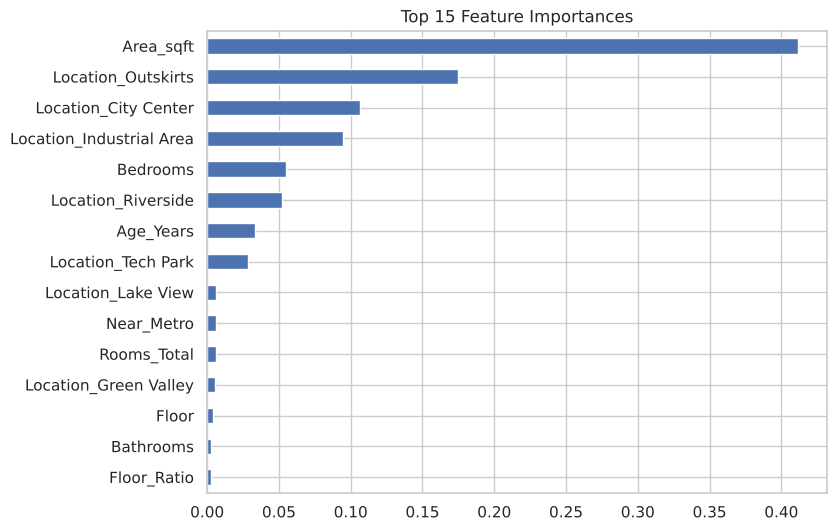

In [22]:
ohe_names = best_model.named_steps['prep'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
feat_names = num_cols + list(ohe_names)
imp = pd.Series(best_model.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
imp.head(15).plot(kind='barh').invert_yaxis()
plt.title('Top 15 Feature Importances'); plt.show()

## 12. Save the model & export predictions to Excel

In [23]:
joblib.dump(best_model, 'models/house_price_model.pkl')

out = X_test.copy()
out['Actual_Price_Lakhs'] = y_test.values
out['Predicted_Price_Lakhs'] = y_pred.round(2)
out['Error_Lakhs'] = (out['Actual_Price_Lakhs'] - out['Predicted_Price_Lakhs']).round(2)
with pd.ExcelWriter('outputs/predictions.xlsx') as w:
    out.to_excel(w, sheet_name='Test_Predictions', index=False)
    results_df.to_excel(w, sheet_name='Model_Comparison', index=False)
print('Saved models/house_price_model.pkl and outputs/predictions.xlsx')

Saved models/house_price_model.pkl and outputs/predictions.xlsx


## 13. Predict the price of a new house

In [24]:
model = joblib.load('models/house_price_model.pkl')

new_house = pd.DataFrame([{
    'Location': 'Tech Park', 'Area_sqft': 1250, 'Bedrooms': 3, 'Bathrooms': 2,
    'Balconies': 2, 'Floor': 6, 'Total_Floors': 12, 'Age_Years': 5,
    'Furnishing': 'Semi-Furnished', 'Parking_Spaces': 1, 'Near_Metro': 'Yes',
}])
# apply the same feature engineering as training
new_house['Floor_Ratio'] = new_house['Floor'] / new_house['Total_Floors']
new_house['Rooms_Total'] = new_house['Bedrooms'] + new_house['Bathrooms']
new_house['Near_Metro'] = new_house['Near_Metro'].map({'Yes': 1, 'No': 0})

price = model.predict(new_house[X.columns])[0]
print(f'Predicted price: ₹ {price:.2f} lakhs  (≈ ₹ {price/100:.2f} crore)')

Predicted price: ₹ 126.65 lakhs  (≈ ₹ 1.27 crore)


## 14. Conclusion
- Cleaned the data (duplicates, extreme outliers) and handled missing values inside a leak-free pipeline.
- Tree-based ensembles clearly beat linear models because price depends on **interactions** (area × location rate).
- The tuned **Gradient Boosting** model is saved and ready for predictions.

**Next steps:** log-transform the target, try XGBoost/LightGBM, or deploy with Streamlit / Flask.